# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch 2026–2027 — Major Project (Data Analytics)

**Problem Statement:** Agricultural performance is influenced by seasonal variation in environmental conditions, farming practices, resource availability and market conditions. This notebook analyzes a seasonal agriculture dataset to identify meaningful patterns, trends, relationships and differences in agricultural performance across seasons, and to develop evidence-based recommendations.

**Dataset:** 4,000 farm records spanning 8 states, 10 districts, 8 crops, 3 seasons (Kharif, Rabi, Zaid) and 4 irrigation methods — covering environmental conditions, farming inputs, and economic outcomes.

---
**Name:** *[Sagar Sharma]*
**AICTE Student ID:** *[STU688dcbd0133971754123216]*
**Batch:** VOIS AICTE 2026–2027
---

# 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

# A consistent color scheme for the three seasons, used across every chart in this notebook
SEASON_ORDER  = ['Kharif', 'Rabi', 'Zaid']
SEASON_COLORS = {'Kharif': '#2E8B57', 'Rabi': '#DAA520', 'Zaid': '#E2571E'}

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 4000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


# 2. Understanding the Dataset
### Before analyzing seasonal patterns, we first check the structure of the data, its data types, and whether it needs cleaning.

In [2]:
print("Column data types:\n")
print(df.dtypes)

print("\nMissing values per column:\n")
missing = df.isnull().sum()
print(missing[missing > 0])

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Column data types:

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        in

In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,3952.0,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,3960.0,26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00


# 3. Data Cleaning
Three columns contain missing values: `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`.

Instead of filling these with the **overall** median, we fill them with the **season-wise median**. This matters because rainfall, soil moisture and yield genuinely differ from one season to another — using a single overall median would quietly bias records toward whichever pattern is most common in the data, and would distort the very seasonal comparison this project is meant to investigate.

In [4]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Missing values remaining:", df.isnull().sum().sum())
print("Duplicate rows remaining:", df.duplicated().sum())

Missing values remaining: 0
Duplicate rows remaining: 0


# 4. Dataset Overview — Records by Season and Crop

/tmp/ipykernel_1680/471256816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Season', order=SEASON_ORDER, palette=SEASON_COLORS, ax=axes[0])
/tmp/ipykernel_1680/471256816.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Crop', order=df['Crop'].value_counts().index, palette='viridis', ax=axes[1])


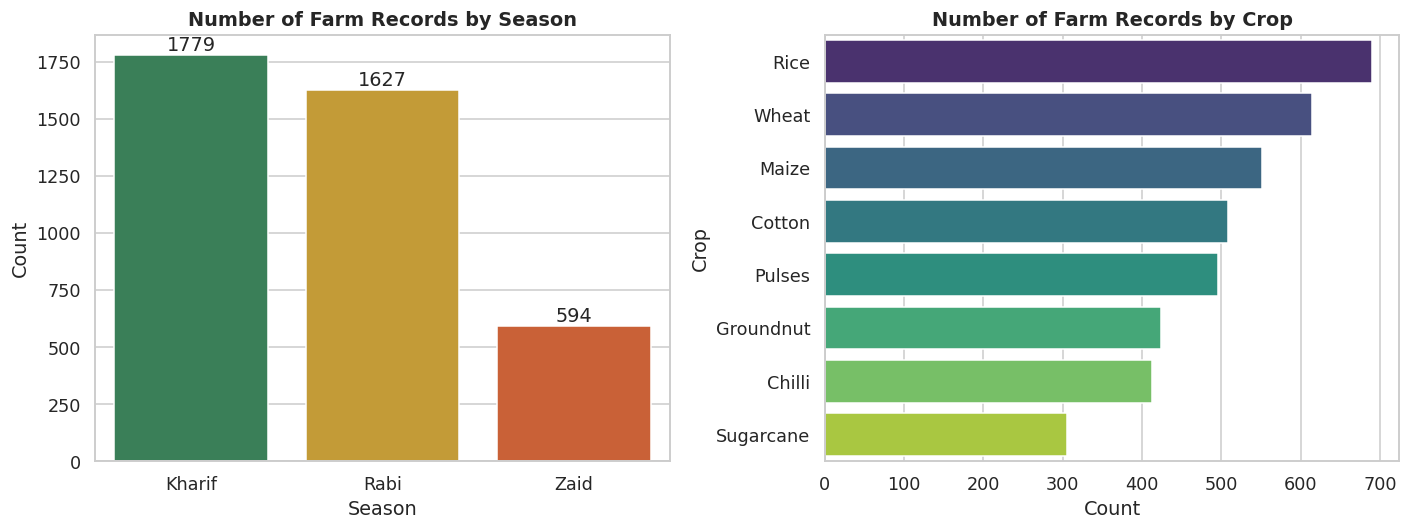

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='Season', order=SEASON_ORDER, palette=SEASON_COLORS, ax=axes[0])
axes[0].set_title('Number of Farm Records by Season')
axes[0].set_ylabel('Count')
for c in axes[0].containers:
    axes[0].bar_label(c)

sns.countplot(data=df, y='Crop', order=df['Crop'].value_counts().index, palette='viridis', ax=axes[1])
axes[1].set_title('Number of Farm Records by Crop')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

# 5. How Does Agricultural Performance Vary Across Seasons?
We look at the two core performance indicators — **Yield** (agronomic output) and **Profit** (economic output) — across the three seasons.

/tmp/ipykernel_1680/295847854.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, palette=SEASON_COLORS, ax=axes[0])
/tmp/ipykernel_1680/295847854.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER, palette=SEASON_COLORS, ax=axes[1])


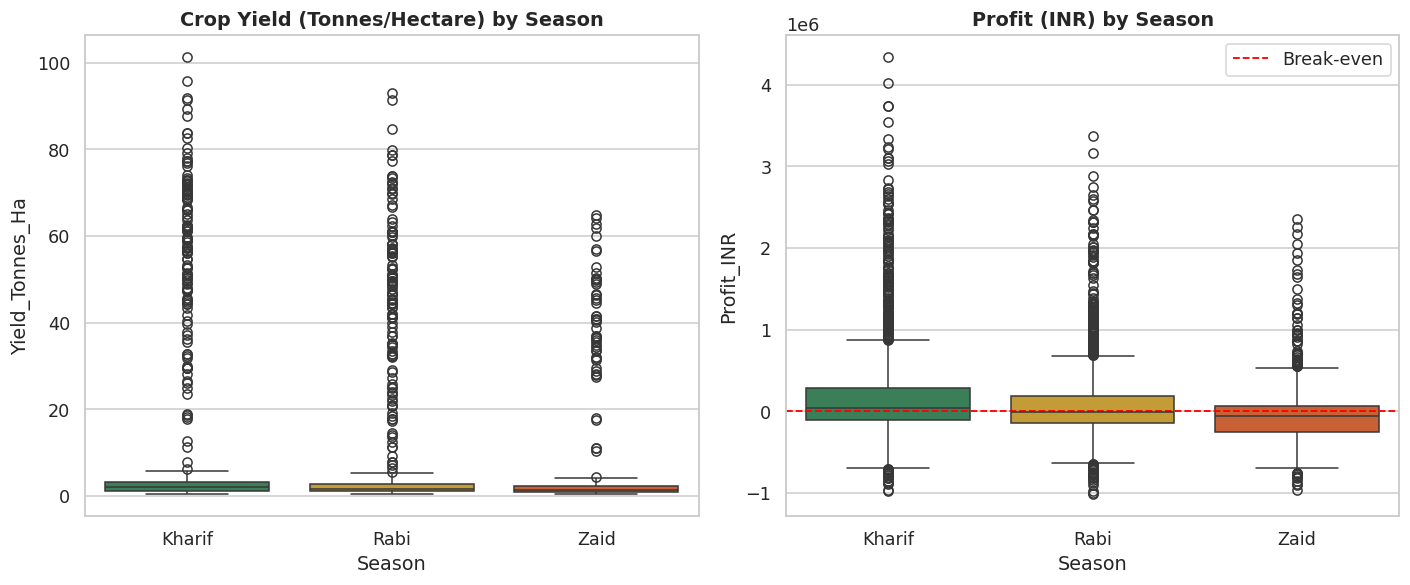

Yield_Tonnes_Ha        Profit_INR         
                  mean median       mean   median
Season                                           
Kharif            5.63   1.95  178914.65  38808.0
Rabi              5.04   1.66   87689.47  -3187.0
Zaid              4.64   1.45  -24804.82 -62144.0

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, palette=SEASON_COLORS, ax=axes[0])
axes[0].set_title('Crop Yield (Tonnes/Hectare) by Season')

sns.boxplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER, palette=SEASON_COLORS, ax=axes[1])
axes[1].set_title('Profit (INR) by Season')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2, label='Break-even')
axes[1].legend()

plt.tight_layout()
plt.show()

summary = df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR']].agg(['mean', 'median']).reindex(SEASON_ORDER)
summary.round(2)

In [7]:
# What share of farms actually made a loss, season by season?
loss_share = df.groupby('Season').apply(lambda g: (g['Profit_INR'] < 0).mean() * 100).reindex(SEASON_ORDER)
loss_share.name = 'Loss_Making_Farms_pct'
loss_share.round(1)

/tmp/ipykernel_1680/2573760362.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loss_share = df.groupby('Season').apply(lambda g: (g['Profit_INR'] < 0).mean() * 100).reindex(SEASON_ORDER)


,Loss_Making_Farms_pct
Season,
Kharif,42.2
Rabi,51.1
Zaid,64.5


# 6. Which Characteristics Change Between Seasons? — Environmental Conditions

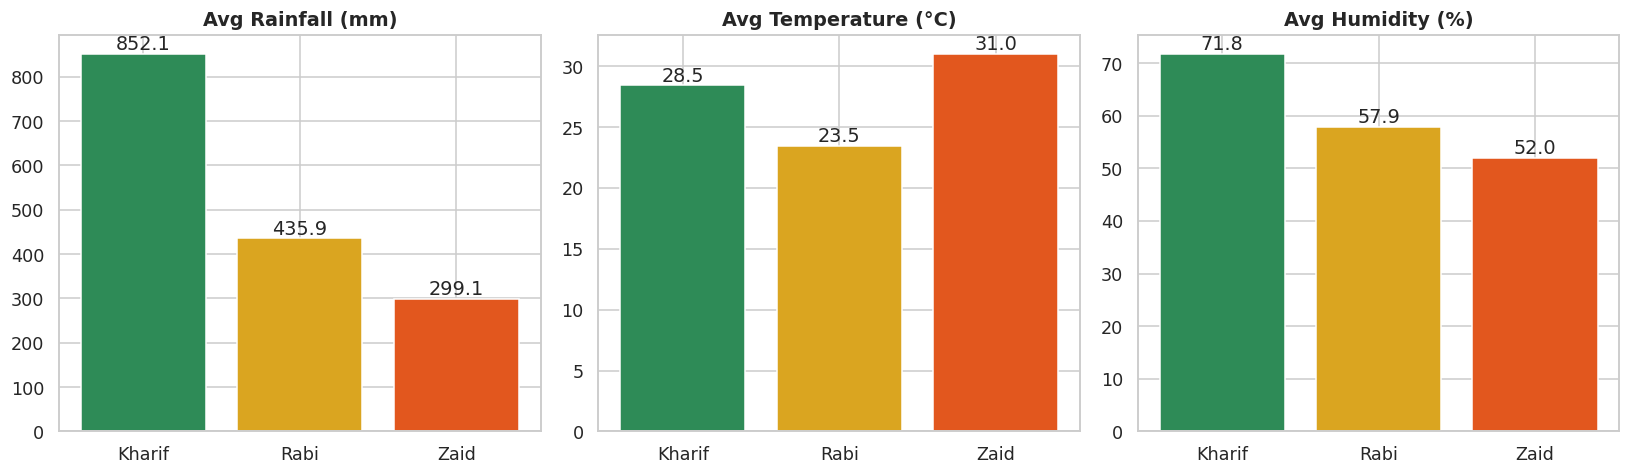

In [9]:
env_means = df.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']].mean().reindex(SEASON_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']
titles  = ['Avg Rainfall (mm)', 'Avg Temperature (°C)', 'Avg Humidity (%)']

for ax, m, t in zip(axes, metrics, titles):
    bars = ax.bar(SEASON_ORDER, env_means[m], color=[SEASON_COLORS[s] for s in SEASON_ORDER])
    ax.set_title(t)
    ax.bar_label(bars, fmt='%.1f')

plt.tight_layout()
plt.show()

# 7. Are There Variations in Resource Usage Across Seasons?

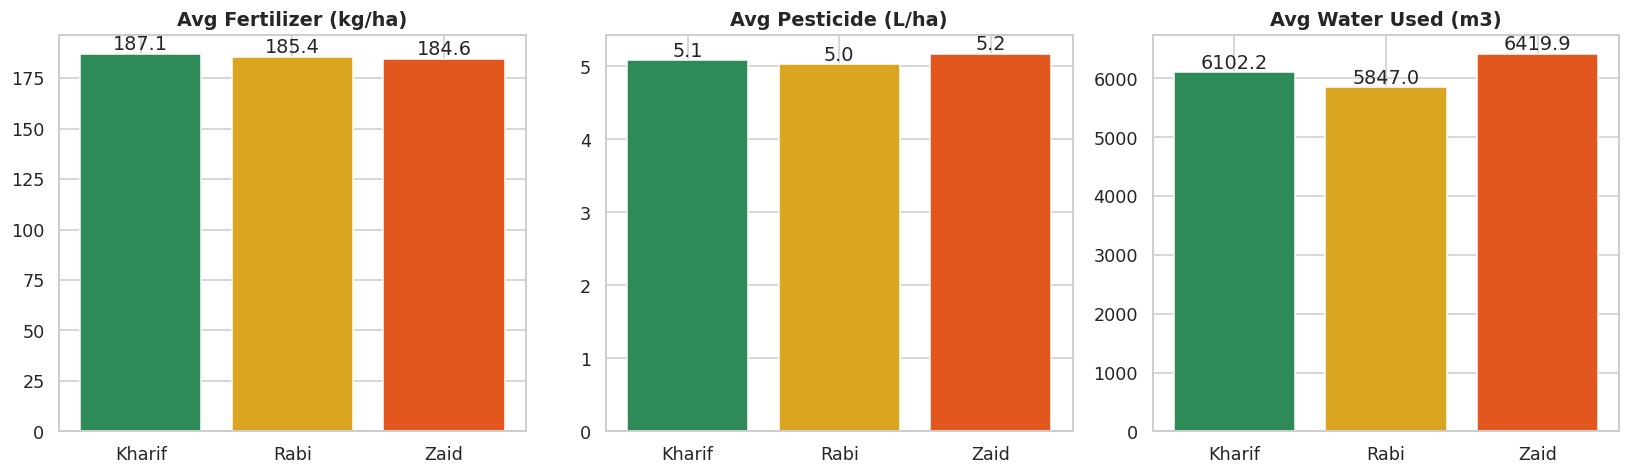

In [10]:
res_means = df.groupby('Season')[['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3']].mean().reindex(SEASON_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3']
titles  = ['Avg Fertilizer (kg/ha)', 'Avg Pesticide (L/ha)', 'Avg Water Used (m3)']

for ax, m, t in zip(axes, metrics, titles):
    bars = ax.bar(SEASON_ORDER, res_means[m], color=[SEASON_COLORS[s] for s in SEASON_ORDER])
    ax.set_title(t)
    ax.bar_label(bars, fmt='%.1f')

plt.tight_layout()
plt.show()

# 8. How Do Economic Outcomes Vary Across Seasons?

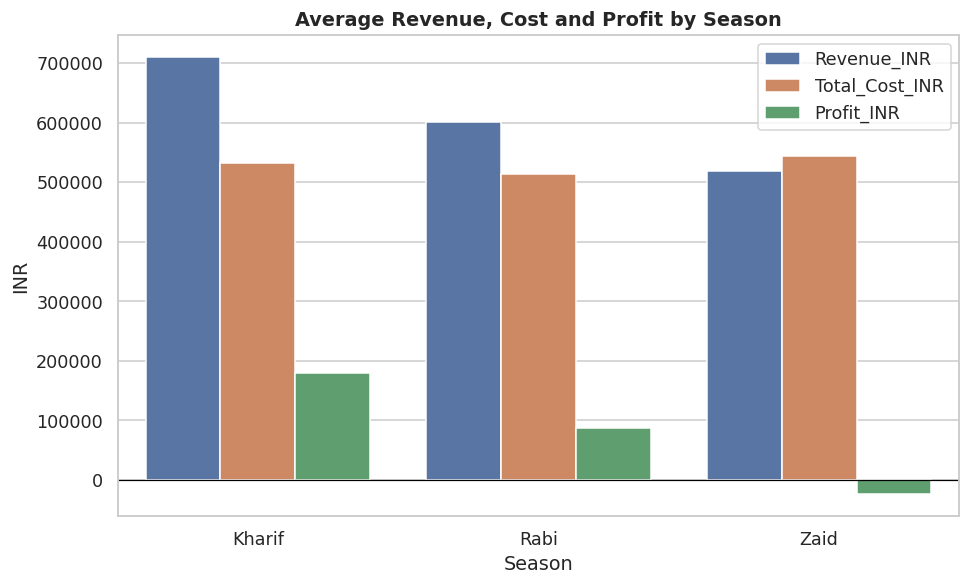

In [11]:
econ = df.groupby('Season')[['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']].mean().reindex(SEASON_ORDER).reset_index()
econ_melt = econ.melt(id_vars='Season', var_name='Metric', value_name='Amount_INR')

plt.figure(figsize=(9, 5.5))
sns.barplot(data=econ_melt, x='Season', y='Amount_INR', hue='Metric', order=SEASON_ORDER,
            palette=['#4C72B0', '#DD8452', '#55A868'])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Revenue, Cost and Profit by Season')
plt.ylabel('INR')
plt.legend(title='')
plt.tight_layout()
plt.show()

# 9. Relationships Between Environmental Conditions and Performance

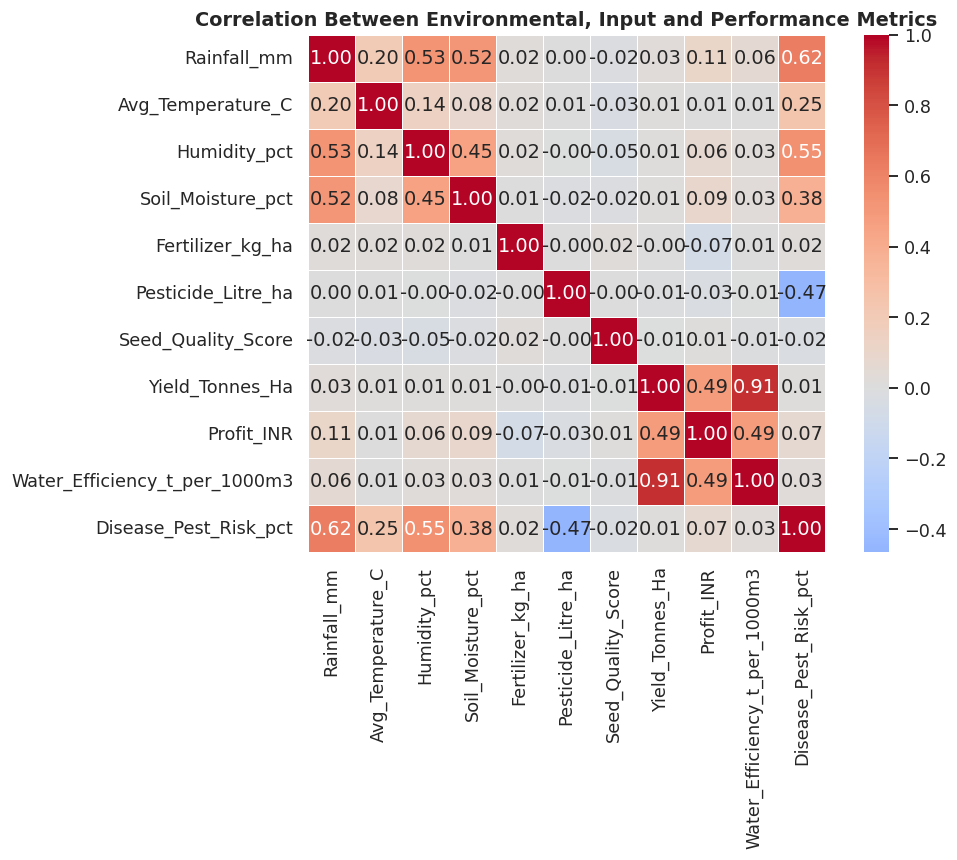

In [12]:
key_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
            'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
            'Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

plt.figure(figsize=(10, 8))
corr = df[key_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Correlation Between Environmental, Input and Performance Metrics')
plt.tight_layout()
plt.show()

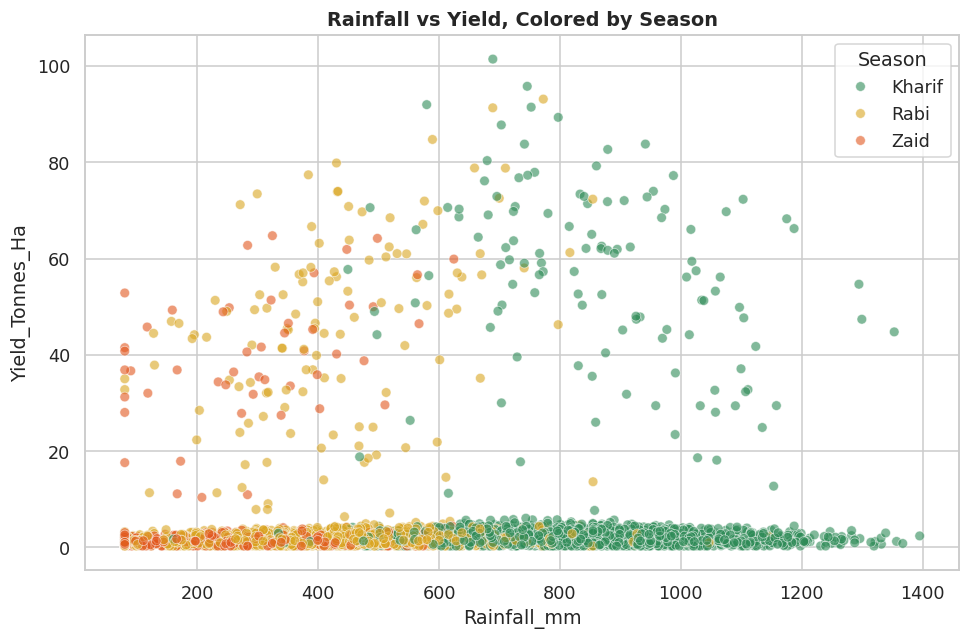

In [13]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', hue_order=SEASON_ORDER,
                 palette=SEASON_COLORS, alpha=0.6, s=40)
plt.title('Rainfall vs Yield, Colored by Season')
plt.tight_layout()
plt.show()

# 10. Irrigation Efficiency Across Seasons

/tmp/ipykernel_1680/1516032653.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', col='Season',


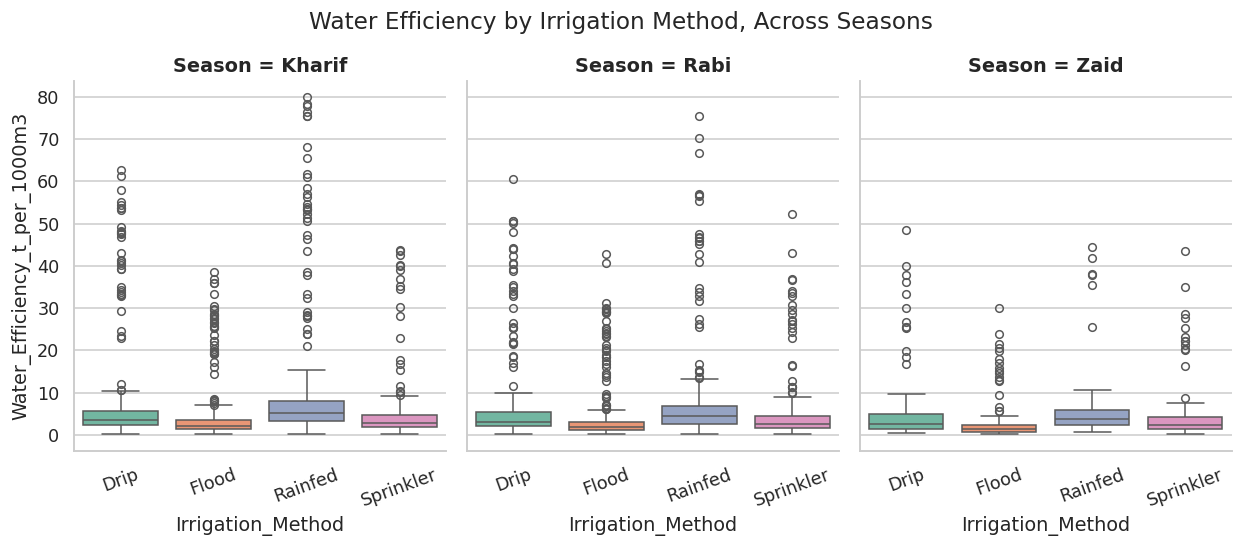

In [14]:
g = sns.catplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', col='Season',
                 col_order=SEASON_ORDER, kind='box', palette='Set2', height=4.5, aspect=0.85)
g.fig.suptitle('Water Efficiency by Irrigation Method, Across Seasons', y=1.05)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=20)
plt.show()

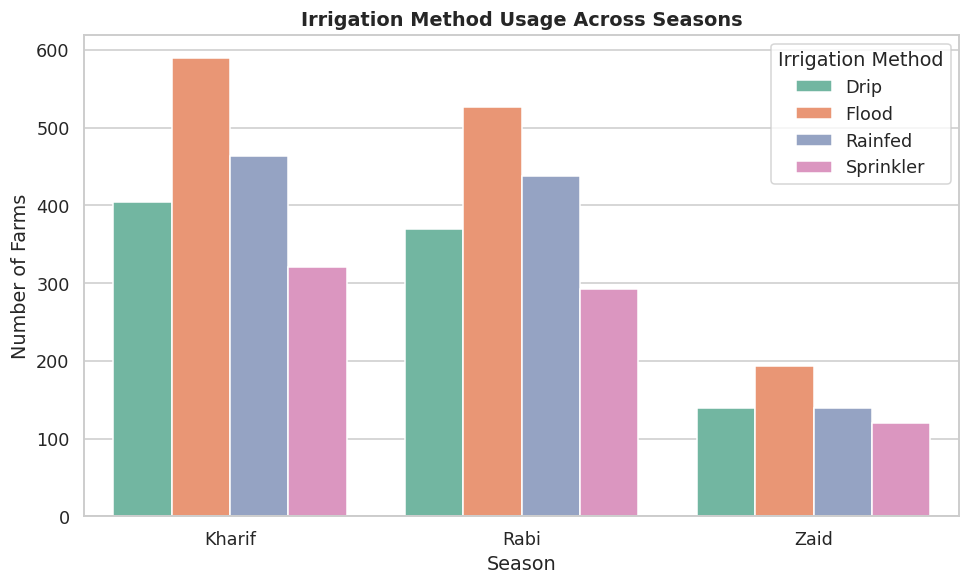

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


In [15]:
plt.figure(figsize=(9, 5.5))
sns.countplot(data=df, x='Season', hue='Irrigation_Method', order=SEASON_ORDER, palette='Set2')
plt.title('Irrigation Method Usage Across Seasons')
plt.ylabel('Number of Farms')
plt.legend(title='Irrigation Method')
plt.tight_layout()
plt.show()

# Same info as a table, in percentage form
irrigation_pct = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index') * 100
irrigation_pct.reindex(SEASON_ORDER).round(1)

# 11. Which Crop Performs Best in Which Season?

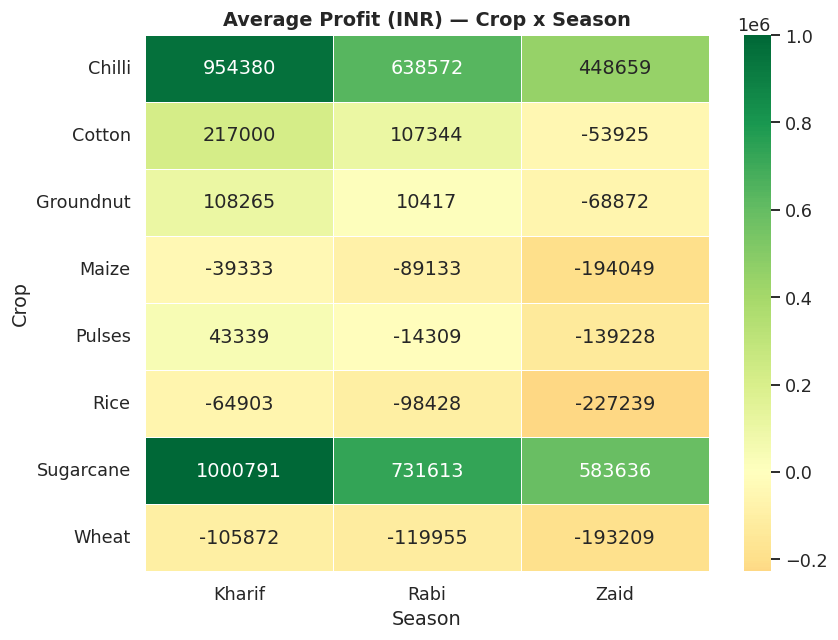

In [16]:
pivot_profit = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean')[SEASON_ORDER]

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Average Profit (INR) — Crop x Season')
plt.tight_layout()
plt.show()

# 12. Disease and Pest Risk Across Seasons

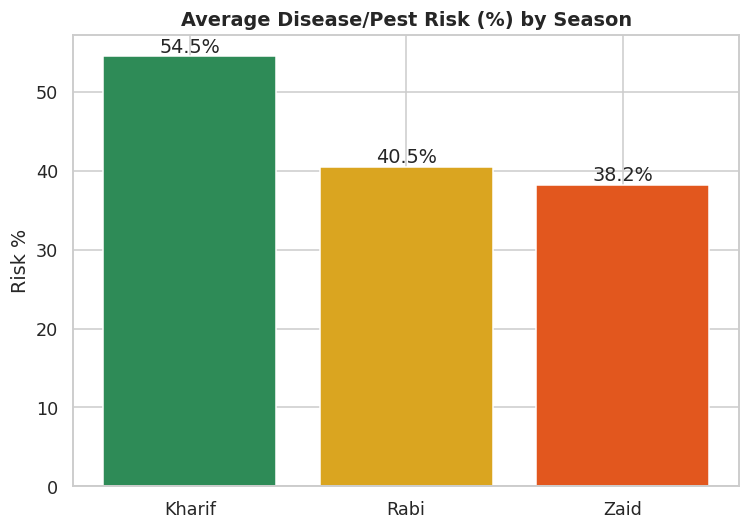

In [17]:
plt.figure(figsize=(7, 5))
risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(SEASON_ORDER)
bars = plt.bar(SEASON_ORDER, risk, color=[SEASON_COLORS[s] for s in SEASON_ORDER])
plt.bar_label(bars, fmt='%.1f%%')
plt.title('Average Disease/Pest Risk (%) by Season')
plt.ylabel('Risk %')
plt.tight_layout()
plt.show()

# 13. Are Seasonal Patterns Consistent Across States?

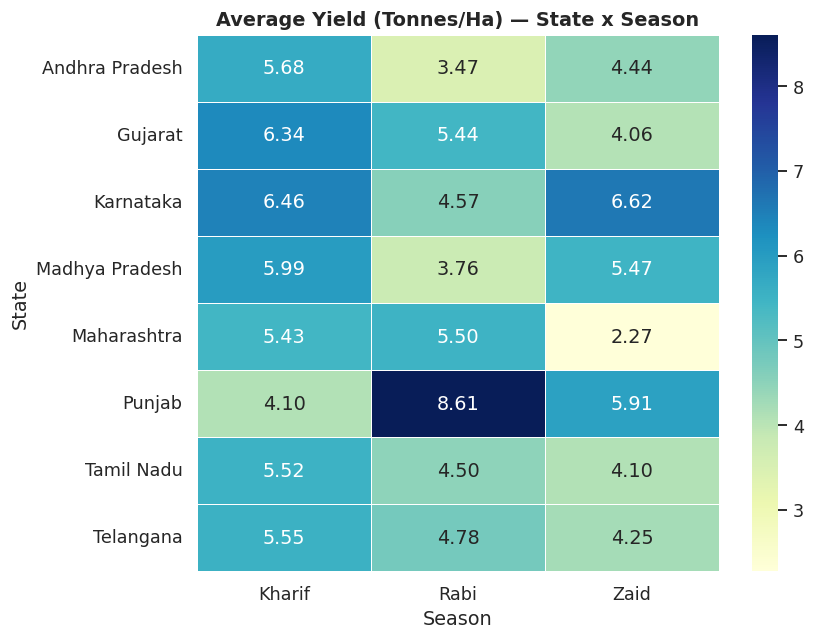

In [18]:
state_pivot = df.pivot_table(index='State', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean')[SEASON_ORDER]

plt.figure(figsize=(8, 6))
sns.heatmap(state_pivot, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5)
plt.title('Average Yield (Tonnes/Ha) — State x Season')
plt.tight_layout()
plt.show()

# 14. Statistical Test — Are Seasonal Differences Significant?
A boxplot can *suggest* a seasonal difference, but a one-way ANOVA test tells us whether that difference is statistically significant, or could just be random variation.

In [19]:
groups_y = [df[df.Season == s]['Yield_Tonnes_Ha'] for s in SEASON_ORDER]
f_y, p_y = stats.f_oneway(*groups_y)
print(f"ANOVA on Yield across Season   -> F = {f_y:.3f}, p = {p_y:.4f}")
print("  Significant (p < 0.05)?" , "Yes" if p_y < 0.05 else "No")

groups_p = [df[df.Season == s]['Profit_INR'] for s in SEASON_ORDER]
f_p, p_p = stats.f_oneway(*groups_p)
print(f"\nANOVA on Profit across Season  -> F = {f_p:.3f}, p = {p_p:.2e}")
print("  Significant (p < 0.05)?", "Yes" if p_p < 0.05 else "No")

ANOVA on Yield across Season   -> F = 1.554, p = 0.2116
  Significant (p < 0.05)? No

ANOVA on Profit across Season  -> F = 34.292, p = 1.71e-15
  Significant (p < 0.05)? Yes


# 15. Key Findings

### 1. **Yield trends down across seasons but the difference is not statistically strong.** Average yield falls from 5.63 t/ha (Kharif) → 5.04 t/ha (Rabi) → 4.64 t/ha (Zaid), but a one-way ANOVA gives p ≈ 0.21 — the within-season variation is large enough that this trend cannot be confidently generalized from yield alone.

### 2. **Profit differs sharply and significantly across seasons (ANOVA p < 0.001).** Average profit falls from ₹1.79 lakh (Kharif) to ₹0.88 lakh (Rabi) to a **net average loss of ≈ ₹25,000 in Zaid**.

### 3. **The share of loss-making farms rises steadily each season:** 42.2% (Kharif) → 51.1% (Rabi) → 64.5% (Zaid). By Zaid, most farms in the dataset are unprofitable.

### 4. **The profit decline is driven by falling revenue, not falling price.** Average market price is nearly flat across seasons (≈ ₹44,200–44,900/tonne), while average revenue drops from ₹7.1 lakh (Kharif) to ₹5.2 lakh (Zaid) as production volume falls. Meanwhile average cost stays roughly flat (₹5.1–5.4 lakh) — costs do not shrink to match lower output in Zaid, which is what pushes many Zaid farms into a loss.

### 5. **Kharif has the highest rainfall (852 mm) and humidity (72%) but also the highest disease/pest risk (54.5%)**, versus Zaid's lowest risk (38.2%) — a trade-off between favorable growing conditions and pest pressure.

### 6. **Crop choice matters more than season timing.** Sugarcane and Chilli stay strongly profitable in *every* season, while Wheat, Rice and Maize run losses in *every* season in this dataset — the seasonal effect is secondary to which crop is grown.

### 7. **Fertilizer, pesticide and water usage are nearly flat across seasons** (~185 kg/ha fertilizer, ~5 L/ha pesticide in every season), even though yield and profit are not — input usage does not appear to be adjusted seasonally.

### 8. **Rainfall, Fertilizer and Seed Quality each show close to zero linear correlation with Yield individually** (all |r| < 0.03). Yield is likely shaped by a combination of factors rather than any single input acting alone.

# 16. Recommendations

### - **Treat Zaid season as a financial risk zone.** With ~65% of Zaid farms losing money, prioritize cost-control measures (input planning, price negotiation, storage/timing of sale) specifically for the Zaid season rather than assuming the same approach that works in Kharif will work here.
###- **Prioritize crop selection alongside season planning.** Since Sugarcane and Chilli remain profitable across all seasons while Wheat, Rice and Maize do not, seasonal planning should be paired with crop-level profitability review, not treated as a season-only decision.
###- **Investigate the cost side of Zaid farming specifically**, since yield per hectare does not collapse in Zaid but profit does — the gap points to costs not scaling down with lower output, rather than a pure production failure.
###- **Re-evaluate fertilizer/pesticide dosing by season and crop** instead of applying a near-uniform amount, since input levels barely move across seasons despite performance moving substantially.
###- **Use multivariate modeling for future yield prediction**, since no single environmental or input factor correlates strongly with yield in isolation — a combined/interaction-based model would likely explain yield better than any one variable.

# Conclusion
### Agricultural performance in this dataset varies more strongly on the **economic side** (profit, loss rate) than on the **agronomic side** (yield), and season interacts closely with crop choice, cost structure and disease pressure rather than acting as an independent driver on its own. Zaid stands out as the season needing the most attention, primarily due to a revenue-cost imbalance rather than a shortfall in per-hectare productivity.